## Simulation

Small notebook to run the simulation and see what is happening

#### TFIM Local magnetization

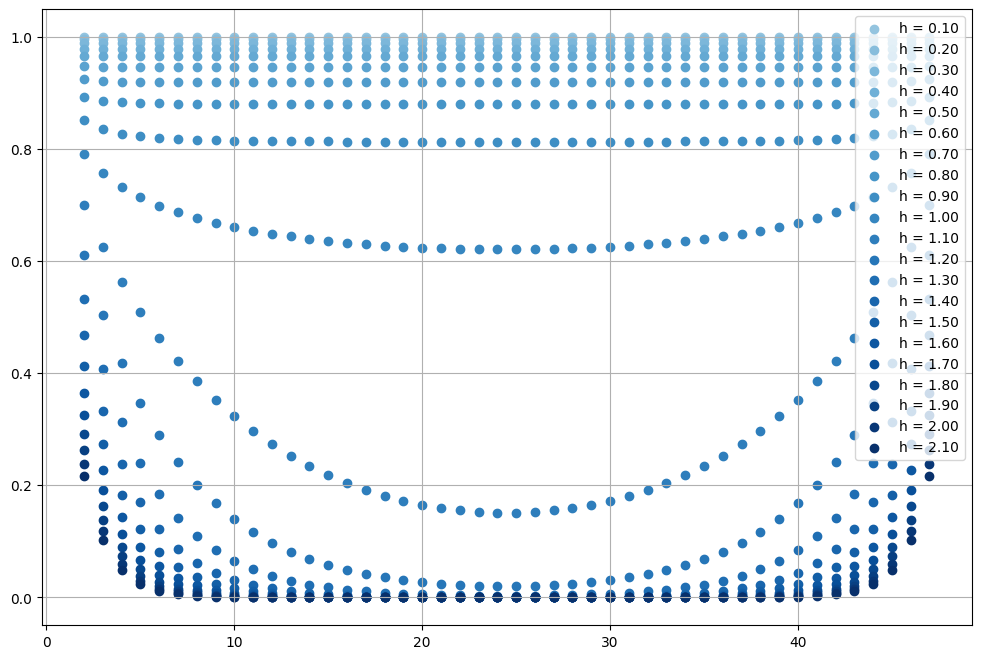

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

outputs = os.path.join(os.getcwd(), "OUT")
cor = cm.Blues(np.linspace(0.4, 1, 21))
values = []
h_indices = []
plt.figure(figsize=(12, 8))

for index, h_value in enumerate(sorted(os.listdir(outputs))):
    result = os.path.join(outputs, h_value)

    arr = np.loadtxt(os.path.join(result, "Z.txt"))
    arr = arr.T
    values.append(min(arr[1]))
    h_indices.append(h_value.split("_")[1])
    plt.scatter(arr[0], arr[1], color=cor[index], label=f"h = {h_value.split("_")[1]}")


plt.legend(loc="upper right")
plt.grid()
plt.show()


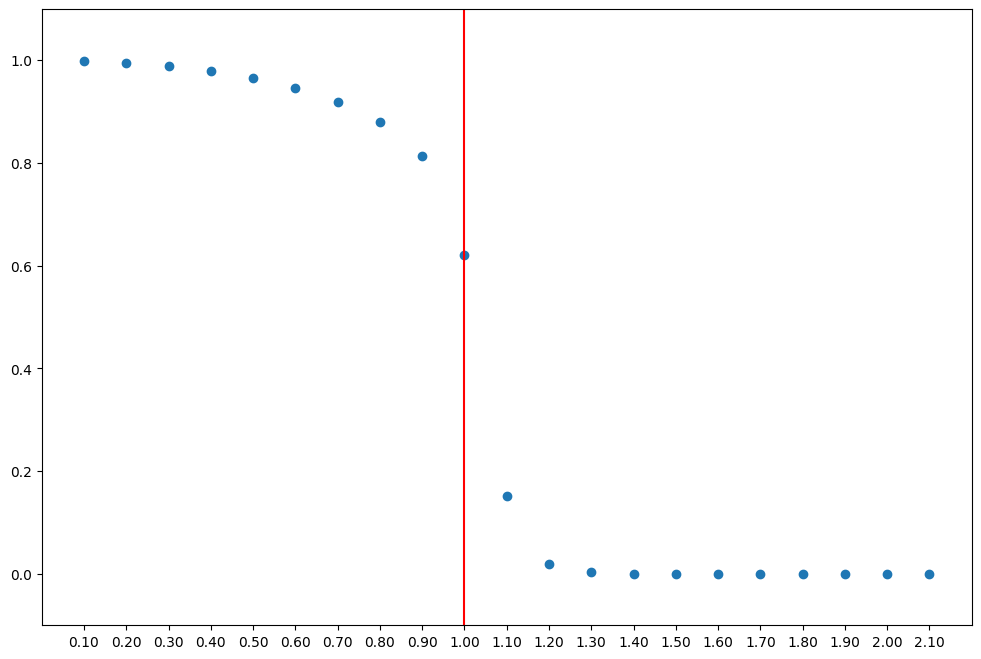

In [37]:
plt.figure(figsize=(12, 8))
plt.scatter(h_indices, values, label="L = 50")
plt.ylim((min(values)-.1, max(values)+.1))
plt.vlines(9, min(values)-.1, max(values)+.1, colors='red')

#### Data processing of values

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# change home directory to OUT
home = os.getcwd()
os.chdir("..")
dir = os.path.join(os.getcwd(), "OUT/First_Run")

# extract data
results = np.zeros((11, 21))
results2 = np.zeros((11, 21), dtype=str)
for ind, file in enumerate(os.listdir(dir)):
    name = file.split("_")
    h = float(name[1])
    k = float(name[2])

    loc = os.path.join(dir, file)
    magnetization = np.loadtxt(os.path.join(loc, "Z.txt")).T
    mag2 = np.loadtxt(os.path.join(loc, "ZZ.txt"), dtype=str).T

    results[int((h)*5)][int((k + 2))*5] = min(magnetization[1])
    results2[int((h)*5)][int((k + 2))*5] = min(mag2[1])

# reset the home directory after each run
os.chdir(home)
print(results.shape)

(11, 21)


In [7]:
%matplotlib notebook

##### Checking for convergence

In [ ]:
# TODO: Check for convergence with energy

#### Magnetization Plotting

##### Plotting via 3d scatter

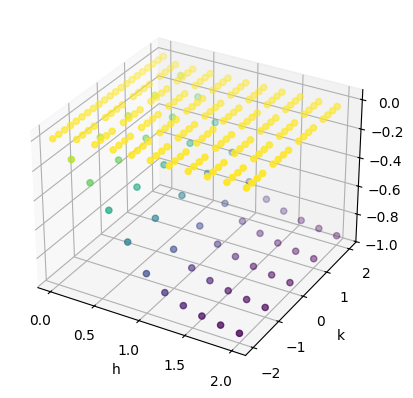

In [ ]:

fig = plt.figure()
ax = plt.axes(projection="3d")
X, Y = np.meshgrid(np.arange(0, 2.1, 0.2), np.arange(-2, 2.1, 0.2))
ax.scatter(X, Y, results.T, c=results.T)
ax.set_xlabel("h")
ax.set_ylabel("k")

plt.show()

##### Plotting via imshow

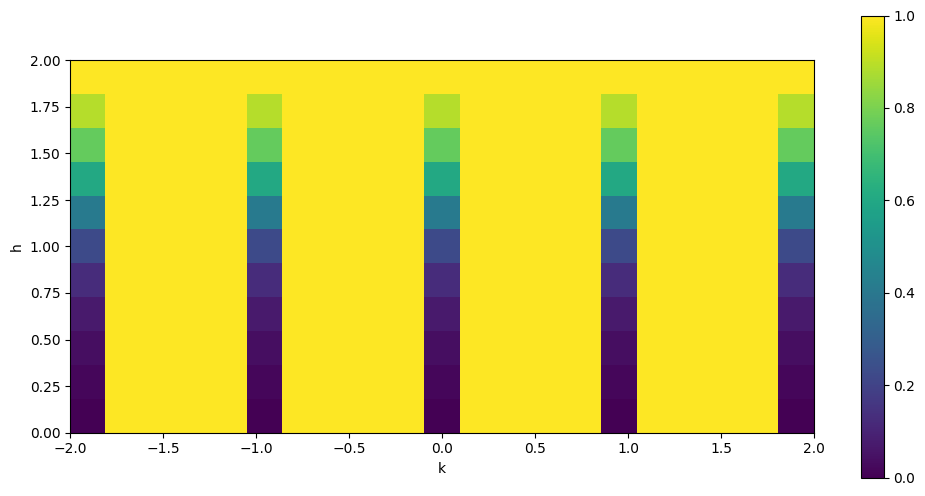

In [25]:
from matplotlib import cm
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(results, interpolation='none', extent=[-2, 2, 0, 2])
fig.colorbar(cm.ScalarMappable(), ax=ax)
ax.set_xlabel("k")
ax.set_ylabel('h')
plt.show()

# plt.imshow(results)

##### Plotting via 2d scatter

/tmp/ipykernel_16030/472114203.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


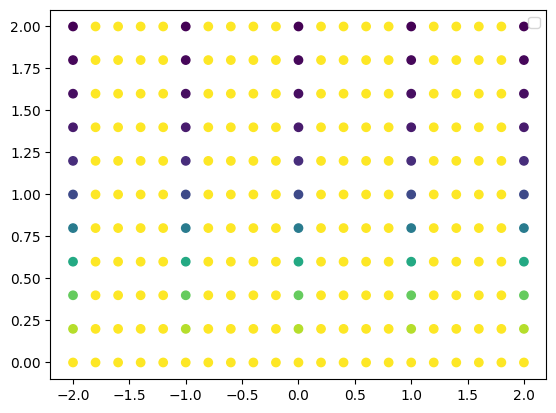

In [ ]:
y = np.arange(0, 2.1, 0.2)
x = np.arange(-2, 2.1, 0.2)

x, y = np.meshgrid(x, y)
plt.scatter(x, y, c=results)
plt.colorbar
plt.show()

#### Entanglement Entropy